<a href="https://colab.research.google.com/github/ragulsulochana/Ragul-codeboosters-2026/blob/main/DAY%202/mini_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import matplotlib.pyplot as plt
import sqlite3 as sql
import pandas as pd
conn = sql.connect('college.db')
cursor = conn.cursor()

# Create the 'college' table from student_performance.csv if it doesn't exist
try:
    df_students = pd.read_csv('student_performance.csv')
    df_students.to_sql('college', conn, if_exists='replace', index=False)
    print("Table 'college' created/replaced from student_performance.csv")
except Exception as e:
    print(f"Error creating/replacing table: {e}")

chart_sql = """
SELECT gender , AVG(attendance_percentage) AS avg_attendance
FROM college
GROUP BY department
ORDER BY attendance_percentage DESC
"""
data = pd.read_sql(chart_sql,conn)
print("=== DataBase Connected Successfully ===")
print("")
print(data)
conn.close()

Table 'college' created/replaced from student_performance.csv
=== DataBase Connected Successfully ===

   gender  avg_attendance
0  Female       83.500000
1    Male       90.692308
2    Male       74.600000
3    Male       80.333333


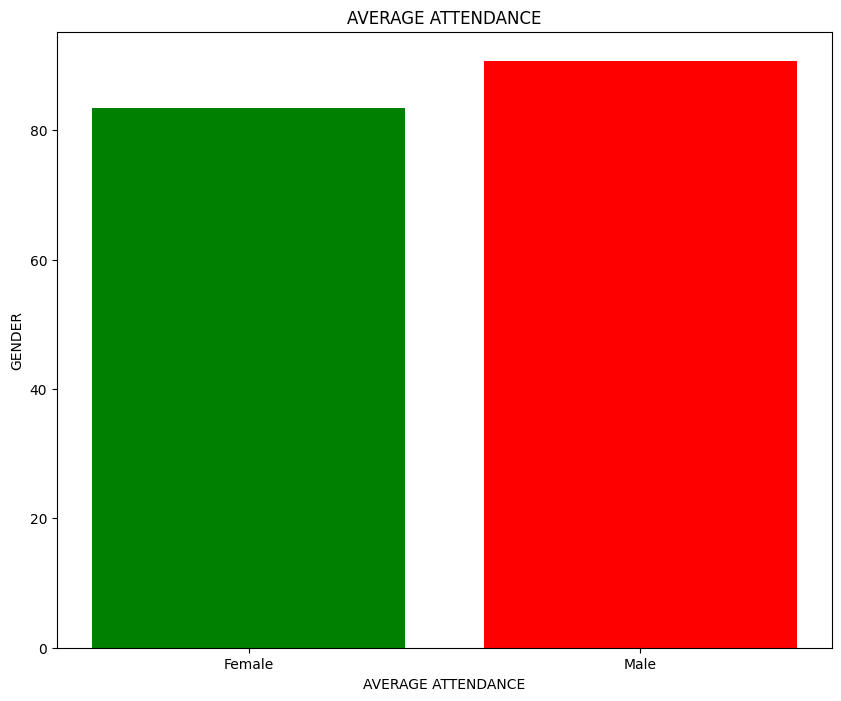

In [5]:
ax , fig = plt.subplots(figsize=(10,8))
plt.title("AVERAGE ATTENDANCE")
plt.ylabel("GENDER")
plt.xlabel("AVERAGE ATTENDANCE")
plt.bar(data['gender'],data['avg_attendance'], color = ['green','red'])
plt.show()

In [7]:
import matplotlib.pyplot as plt
import sqlite3 as sql
import pandas as pd

conn = sql.connect('internship.db')
cursor = conn.cursor()

# Create the 'internship' table from student_performance.csv if it doesn't exist
try:
    df_students = pd.read_csv('student_performance.csv')
    df_students.to_sql('internship', conn, if_exists='replace', index=False)
    print("Table 'internship' created/replaced from student_performance.csv")
except Exception as e:
    print(f"Error creating/replacing table: {e}")

chart_sql = """
SELECT name , (math_score + programming_score + math_score + science_score + english_score) AS total_score
FROM internship
ORDER BY total_score
LIMIT 8;
"""
data = pd.read_sql(chart_sql,conn)
print("=== DataBase Connected Successfully ===")
print("")
print(data)
conn.close()

Table 'internship' created/replaced from student_performance.csv
=== DataBase Connected Successfully ===

             name  total_score
0    Manoj Pandey          266
1    Sanjay Dubey          289
2   Sunita Pillai          292
3    Rahul Mishra          298
4     Meera Joshi          304
5     Rohit Verma          320
6     Kiran Kumar          320
7  Deepak Chauhan          320


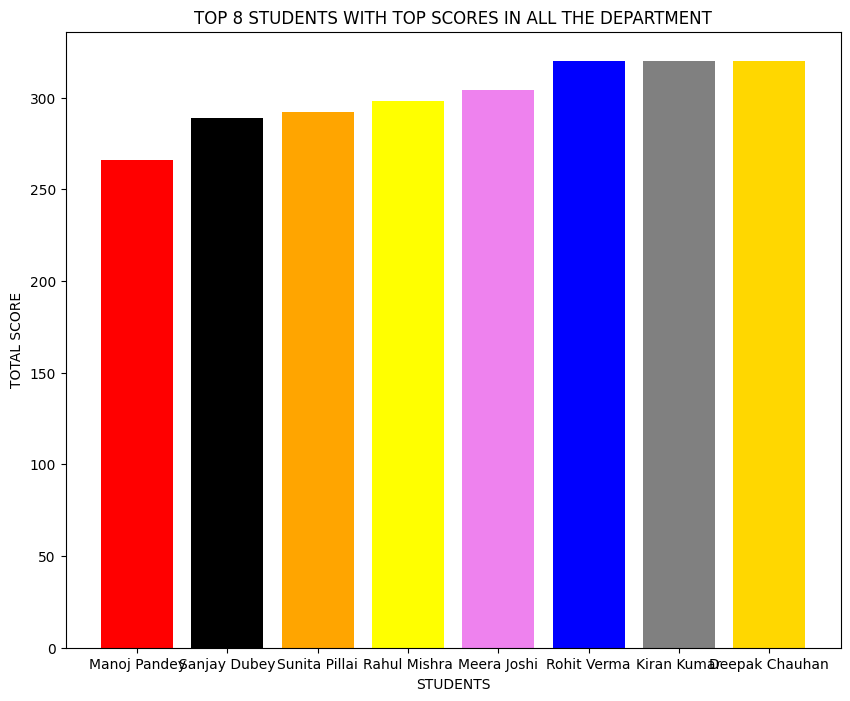

In [8]:
fig , ax = plt.subplots(figsize=(10,8))
plt.title("TOP 8 STUDENTS WITH TOP SCORES IN ALL THE DEPARTMENT")
plt.xlabel("STUDENTS")
plt.ylabel("TOTAL SCORE")
plt.bar(data['name'],data['total_score'], color = ['red','black','orange','yellow','violet','blue','grey','gold'])
plt.show()